# || NEMO SANDBOX  ||
© _Konstantinos Andreadis_ (Roux Lab & Salbreux Lab @UNIGE)

In [3]:
# Import custom scripts
from scripts import analysis, datahandler, visuals, simulation
from importlib import reload

for module in (analysis, datahandler, visuals, simulation):
    reload(module)

# Import python essentials
import os
import numpy as np
from timeit import default_timer as timer
import matplotlib.pyplot as plt
import itertools
import trimesh
import scipy.spatial

In [ ]:

img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/DEBUG/debug.tiff"

# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/segmentation_examples/72.tif"
# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/segmentation_examples/96.tif"
# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/segmentation_examples/120.tif"

# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/oriane/fish2_scale1_3dpp_SHGt.tif"
# img_path = r"/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/clean_multi-layer/sphere_mx_denoised_cleaned.tif"

# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/magdalena_embl/time-lapse/CTL_TG_His_lyn_E25_20230926_block1_New-01And-2To7-TP10To13.tif"

In [ ]:
# parser.add_argument("--img_path", type=str,
#                     default="/Users/andreadi/Downloads/CTL_TG_His_lyn_E25_20230926_block1_New-01And-2To7-TP10To13.tif",
#                     help="Path to the input TIFF image")
# parser.add_argument("--result_path", type=str, default="/Users/andreadi/Downloads/cluster_result/",
#                     help="Path to result folder")

In [ ]:
n_range = [2, 5, 10, 20, 50, 100, 200, 500, 1000]  # number of directors
k = 10000  # number of random draws
nematic_order_all = np.empty((len(n_range), k))
for i_n, n in enumerate(n_range):
    random_theta = np.random.uniform(-np.pi / 2, np.pi / 2, size=(k, n))
    random_dirfield = np.empty((k, n, 4))
    random_dirfield[:, :, 0:2] = 1.0  # not used
    random_dirfield[:, :, 2] = np.cos(random_theta)
    random_dirfield[:, :, 3] = np.sin(random_theta)
    # visuals.plot_polar_hist(np.degrees(random_theta))
    neigh_idxs = np.arange(n)
    S_values = np.empty(k)
    for i in range(k):
        S_values[i] = analysis.avg_2d_nem_tens(
            directors=random_dirfield[i], neigh_idxs=np.array([np.arange(n)]))[0][0]
    print(f"n = {n} k = {k} | Mean S = {np.mean(S_values)}")
    nematic_order_all[i_n] = S_values
    # visuals.plot_hist(S_values, xlim=[0, 1], title=f"bin size n = {n} | repeated for k = {k} | Nematic order $S$")
plt.figure(figsize=(10, 8))
plt.title(f"Nematic order $S$ calculated for $n$ directors | k = {k} random draws")
for i_n, S_order_dist in enumerate(nematic_order_all):
    plt.hist(S_order_dist, bins=50, color=plt.get_cmap('rainbow')(i_n / len(nematic_order_all)),
             label=f"n = {n_range[i_n]}", alpha=0.8)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="number of directors $n$")
plt.show()

mean_S = np.mean(nematic_order_all, axis=1)
min_S = np.min(nematic_order_all, axis=1)
max_S = np.max(nematic_order_all, axis=1)

plt.figure()
plt.title("Nematic order $S$")
plt.plot(n_range, mean_S, "o-", label="mean", color="C0")
plt.fill_between(n_range, min_S, max_S, alpha=0.3, color="C0", label="min–max range")
plt.xlabel("number of directors $n$")
plt.ylabel("Nematic order $S$")
plt.legend()
plt.tight_layout()
plt.show()

# PATHS

In [ ]:
img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/DEBUG/debug.tiff"
# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/magdalena_embl/time-lapse/CTL_TG_His_lyn_E25_20230926_block1_New-01And-2To7-TP10To13.tif"

img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/segmentation_examples/72.tif"
img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/segmentation_examples/96.tif"
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/segmentation_examples/120.tif"

# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/oriane/fish2_scale1_3dpp_SHGt.tif"
img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/DEBUG/debug.tiff"
# path = r"/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/clean_multi-layer/sphere_mx_denoised_cleaned.tif"

In [ ]:
# path = "/Users/andreadi/Desktop/extra_imgs/Uri_PR_runs/72hrs.tif"
# path = "/Users/andreadi/Desktop/extra_imgs/Uri_PR_runs/96hrs.tif"
img_path = "/Users/andreadi/Desktop/extra_imgs/Uri_PR_runs/120hrs.tif"

# path = "/Users/andreadi/Desktop/extra_imgs/Uri_PR_runs/actin_5d.tif"
img_path = "/Users/andreadi/Desktop/extra_imgs/Uri_PR_runs/nuclei_5d.tif"

img_all = analysis.load_img(path=img_path, reduce_xy=1,
                            reduce_z=1,
                            norm_vals=True,
                            custom_scaling=None)
img_raw, img_dim, img_scale, img_unit = img_all
visuals.view_img(img_list=[img_raw], title_list=["Raw Image"], scale=img_scale)

# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/DEBUG/uniform.tiff"
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/DEBUG/debug.tiff"

# path = "/Users/andreadi/Desktop/extra_imgs/Uri_PR_runs/membrane-other_5d.tif"

# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/rosette/C2-003_1.tif"
# path = "/Users/andreadi/Desktop/ellipsoid_mx_main_clean.tif"

# magdalena_root = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/magdalena_embl"
# magdalena_rel_path = "TP1/C1-CTL_TG_His_lyn_E29_20240423_block4_New-02-0To7-TP1.tif"  # == NUCLEI ==
# magdalena_rel_path = "TP1/C2-CTL_TG_His_lyn_E29_20240423_block4_New-02-0To7-TP1.tif"  # == MEMBRANE ==
# magdalena_rel_path = "TP1/C3-CTL_TG_His_lyn_E29_20240423_block4_New-02-0To7-TP1.tif" # == INTERSTITIAL SPACE ==

# magdalena_rel_path = "TP80/C1-CTL_TG_His_lyn_E29_20240423_block4_New-02-0To7-TP80.tif"  # == NUCLEI ==
# magdalena_rel_path = "TP80/C2-CTL_TG_His_lyn_E29_20240423_block4_New-02-0To7-TP80.tif"  # == MEMBRANE ==
# magdalena_rel_path = "TP80/C3-CTL_TG_His_lyn_E29_20240423_block4_New-02-0To7-TP80.tif" # == INTERSTITIAL SPACE ==
# path = os.path.join(magdalena_root, magdalena_rel_path)

In [ ]:
# 72h
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/PR_run/72/exp_2_003.tif"
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/PR_run/72/exp_2_003.tif"

# 96h
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/PR_run/96/1_1.tif"
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/PR_run/96/96 hrs_sun.lif - Series003.tif"

# 120h
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/PR_run/120/58_1.tif"
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/PR_run/120/120hrsflipptr.lif - Series023 - C=0.tif"

# CT
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/PR_run/ctrl/120hrs_mon_CT.lif - TileScan 59:Position 3 - T=0 C=0.tif"

# Actin
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/PR_run/actin_nuclei/actin.tif"

# Nuclei
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/PR_run/actin_nuclei/nuclei.tif"


# path = "/Users/andreadi/Desktop/11MARCH2025/72hrs_sun.lif - Series003.tif"
# path = "/Users/andreadi/Desktop/11MARCH2025/96hrs.lif - Series003.tif"
# path = "/Users/andreadi/Desktop/11MARCH2025/120hrs_ sun1.lif - Series021.tif"

In [ ]:
# ======== [Main] ROOT DATA PATH ========
root_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data"

# ======== [Group] CAPSULE ========
# img_rel_path = "0_capsule/2023/D4/C_003 - Denoised.nd2 - C=1.tif"
# img_rel_path = "0_capsule/2023/D5/C_003 - Denoised - Intensity Equalized.nd2 - C=1.tif"
img_rel_path = "0_capsule/2023/D5/C_002 - Denoised - Intensity Equalized.nd2 - C=1.tif"
# img_rel_path = "0_capsule/2023/D5/C_004 - Denoised - Intensity Equalized.nd2 - C=1.tif"
img_rel_path = "0_capsule/2023/D5/C_004 - Denoised - Intensity Equalized.nd2 - C=0.tif"
# img_rel_path = "0_capsule/2023/D5/C_007 - Denoised - Intensity Equalized.nd2 - C=1.tif"
# img_rel_path = "0_capsule/2023/D20/C_003_Denoised.nd2_C=0.tif"
# img_rel_path = "0_capsule/2023/D20/C_003_Denoised.nd2_C=1.tif"

# ======== [Group] CAPSULE MULTILAYER ========
img_rel_path = "0_capsule/clean_multi-layer/ellipsoid_mx_main_clean.tif"
# img_rel_path = "0_capsule/clean_multi-layer/sphere_mx_denoised_cleaned.tif"
# img_rel_path = "0_capsule/clean_multi-layer/half_multilayer.tif"
# img_rel_path = "0_capsule/LS_2024/D6_c002/C1-D6_C002_nuclei_8bit.tif"
img_rel_path = "0_capsule/LS_2024/D6_c002/C2-D6_C002_actin_8bit.tif"
# img_rel_path = "0_capsule/Live_nuclei/t1/t1-nuclei.tif"

# ======== [Group] GASTRULOID ========
# img_rel_path = "1_gastruloid/rosette/C2-003_1.tif"
# img_rel_path = "1_gastruloid/rosette_2/membrane.tif"
# img_rel_path = "1_gastruloid/first/C2-20230426_Agarose-gastruloid_Day3002-Denoised.tif"
# img_rel_path = "1_gastruloid/ls/membrane/t1.tif"
# img_rel_path = "1_gastruloid/ls/nuclei/t1.tif"

# [[[[===== DATABASE =====]]]]
# img_rel_path = "1_gastruloid/20250203_2p_flipper/120h/3.tif"
img_rel_path = "1_gastruloid/20250203_2p_flipper/120h/4.tif"

# ======== [Group] ORGANOID ========
# img_rel_path = "2_organoid/Position 1_Settings 1_fused/c0_t0001_638_Fused.tif"
# img_rel_path = "2_organoid/20250205_3d_LS/D2_act-membr-nuclei_fused/Position_2_Settings_1_fused/488_actin.tif"
# img_rel_path = "2_organoid/20250205_3d_LS/D2_act-membr-nuclei_fused/Position_2_Settings_1_fused/561_membrane.tif"
# img_rel_path = "2_organoid/20250205_3d_LS/D2_act-membr-nuclei_fused/Position_2_Settings_1_fused/638_nuclei.tif"

# ======== [Group] SIMULATED ========
# img_rel_path = "3_simulated/shell/shell.tiff"
# img_rel_path = "3_simulated/control_shell/shell.tiff"
# img_rel_path = "3_simulated/quentin/shell.tiff"
# img_rel_path = "3_simulated/fibres/fibres.tiff"

# ======== [DEBUG] DEBUG ========
# img_rel_path = "DEBUG/debug.tiff"
# img_rel_path = "DEBUG/uniform.tiff"

# ======== [COLLAB] ZEBRAFISH EMBRYO ========
# img_rel_path = "4_collaborations/magdalena_embl/C2-CTL_TG_His_lyn_E29_20240423_block4_New-02-0To7-TP1.tif"

img_path = os.path.join(root_path, img_rel_path)
# path = "/Users/andreadi/Downloads/120hrs.tif"
# path = '/Volumes/roux/AurelienRouxLab/Oriol/2photon/EXP 1/72h/72 hrsflipptr.lif - Image 2 - C=0.tif'
# path = "/Users/andreadi/Downloads/cylinder_test.tif"
# path = "/Users/andreadi/Downloads/Claire/Mound_02.tif"
# path = "/Users/andreadi/Downloads/Claire/Mound_02_cropped.tif"


# path = '/Users/andreadi/Desktop/11MARCH2025/72hrs_sun.lif - Series003.tif'
# path = '/Users/andreadi/Desktop/11MARCH2025/96hrs.lif - Series003.tif'
# path = '/Users/andreadi/Desktop/11MARCH2025/120hCT.tif'
img_path = '/Users/andreadi/Desktop/11MARCH2025/120hrs_ sun1.lif - Series021.tif'

# path = '/Users/andreadi/Desktop/C1-Actin_dapi_day5_MP.lif - Series007.tif'

In [ ]:
t = datahandler.load_tiff("/Users/andreadi/Desktop/test.tif")
t = np.pad(t, pad_width=100, constant_values=1)
t = analysis.normalise_range(t)
t[t > 0] = 1
t = analysis.gaussian_blur(t, 1, renorm=True)
visuals.plot_matrix(t, origin="upper", cmap="Greys", colorbar=True)
theta = analysis.compute_2d_orientation(mode="fibre", img=t, sampling_box_size=9, onlytheta=True)
visuals.plot_polar_hist(theta[theta != 0])
visuals.plot_matrix(theta, origin="upper", cmap="twilight", colorbar=True, remove_axes=True,
                    savefig="/Users/andreadi/Downloads/test.png")


# 2D+ Charge

In [4]:
mesh = datahandler.load_mesh("/Users/andreadi/Downloads/curved_mesh.ply", recalc_normals=True)

>> Loading mesh /Users/andreadi/Downloads/curved_mesh.ply...
>> Recomputing normals ...


In [5]:
tan_x, tan_y = analysis.create_tangential_basis(mesh.vertex_normals)
random_dirs = simulation.random_tangential(t1=tan_x, t2=tan_y)
random_vecfield = np.column_stack((mesh.vertices, random_dirs))

>> Randomising tangential vector field...


>> Plotting director field...


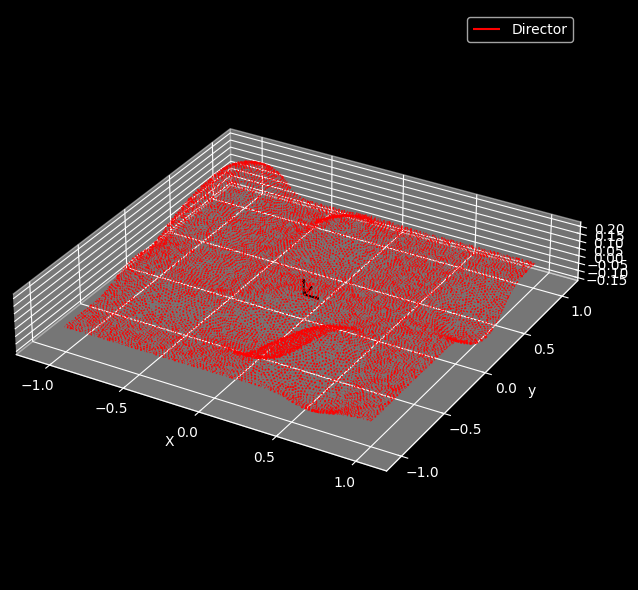

In [6]:
visuals.plot_dir_field(random_vecfield, veclength=0.01)

>> Averaging the nematic tensor in basis t1 t2 ...
>> Plotting director field...


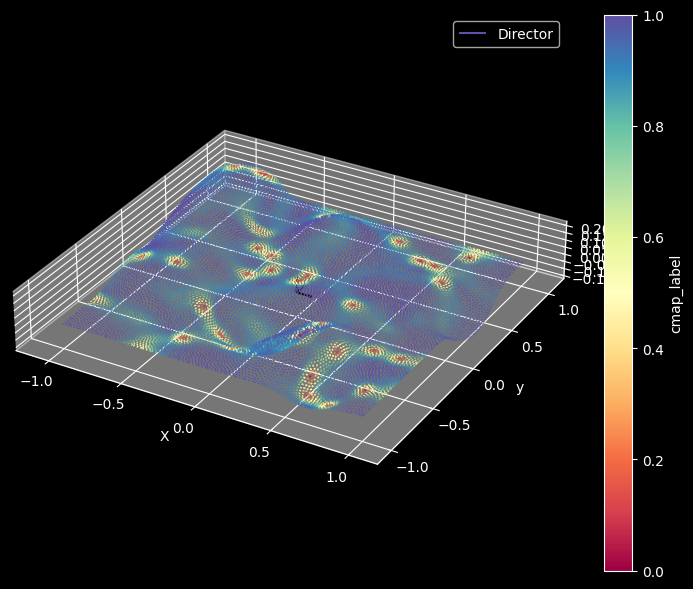

In [15]:
k = 50
S, n = analysis.avg_tan_nem_tens(t1_cov=tan_x, t2_cov=tan_y, directors=random_vecfield,
                                 neigh_idxs=analysis.coord_search_neighbours(random_vecfield[:, :3], k))
random_vecfield[:, 3:] = n
visuals.plot_dir_field(random_vecfield, veccolor=S, manual_vminmax=[0, 1], veclength=0.01)

In [114]:
visuals.view_3d_vector_field(random_vecfield[:, :3], random_vecfield[:, 3:],
                             vec_colors=visuals.color_scalar(S, manual_vminmax=[0, 1]), length=0.02, edge_width=0.005)

>> Rendering 3D vector field...


>> Calculating curvature for mesh with k=40 and 12713 vertices...
Gauss: AVG = 0.32170823581089947 | MIN = -31.71353560963534 | MAX = 42.81180202526038 | None? = 0
Mean: AVG = 0.09945684442001004 | MIN = -7.227660246653079 | MAX = 4.713430045916727 | None? = 0
Number of nans in Gauss: 0
Plotting histogram...


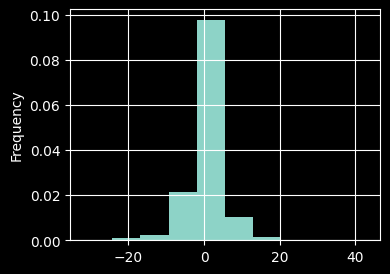

>> Plotting director field...


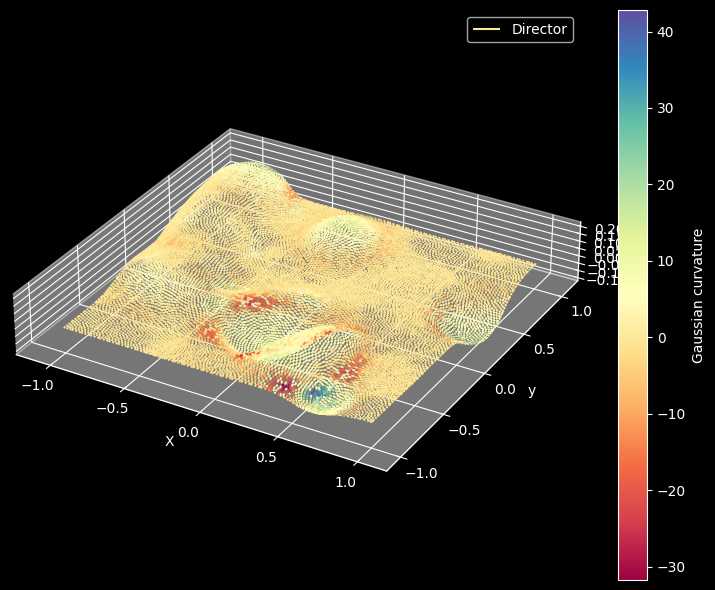

>> Plotting director field...


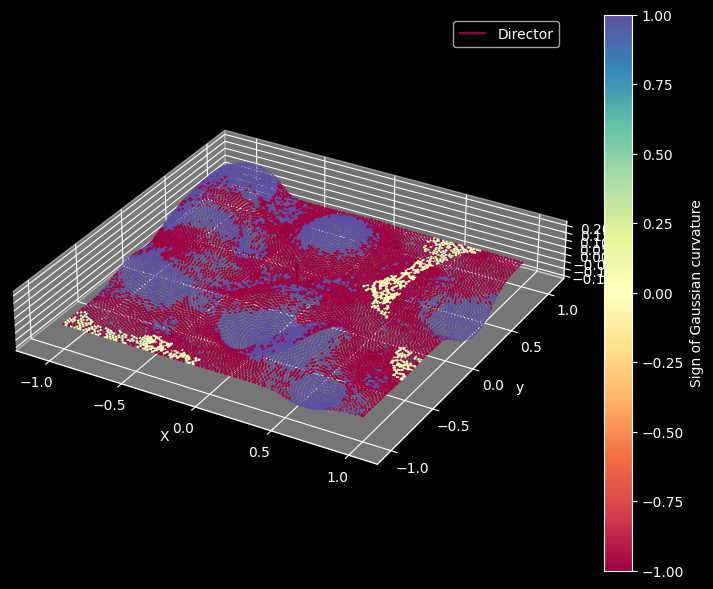

In [16]:
idxs_sel = np.arange(len(mesh.vertices))
k_gauss = 40
C_gauss, _, C_gauss_idxs, _ = analysis.curvature_by_srf_fit(mesh=mesh, k=k_gauss, debug=True,
                                                            gauss_crop_range=None, num_sample=len(mesh.vertices))
uncalc_c_gauss = np.setdiff1d(np.arange(mesh.vertices.shape[0]), C_gauss_idxs)
full_C_gauss = np.full(mesh.vertices.shape[0], np.nan)
full_C_gauss[C_gauss_idxs] = C_gauss
idxs = analysis.coord_search_neighbours(mesh.vertices, k=500)
full_C_gauss[uncalc_c_gauss] = np.nanmean(full_C_gauss[idxs[uncalc_c_gauss]], axis=1)
print(f"Number of nans in Gauss: {np.isnan(full_C_gauss).sum()}")
C_gauss = full_C_gauss
visuals.plot_hist(C_gauss)
visuals.plot_dir_field(directors=random_vecfield, veclength=0.02, veccolor=C_gauss,
                       pt_alpha=1.0, cmap_label="Gaussian curvature", cmap="Spectral")
visuals.plot_dir_field(directors=random_vecfield, veclength=0.02, veccolor=np.sign(C_gauss),
                       pt_alpha=1.0, cmap_label="Sign of Gaussian curvature", cmap="Spectral")

In [113]:
visuals.view_3d_vector_field(random_vecfield[:, :3], random_vecfield[:, 3:],
                             vec_colors=visuals.color_scalar(analysis.normalise_range(C_gauss), cmap="Spectral"),
                             length=0.02, edge_width=0.005)

>> Rendering 3D vector field...


250 valid, 0 invalid ! 
>> Plotting director field...


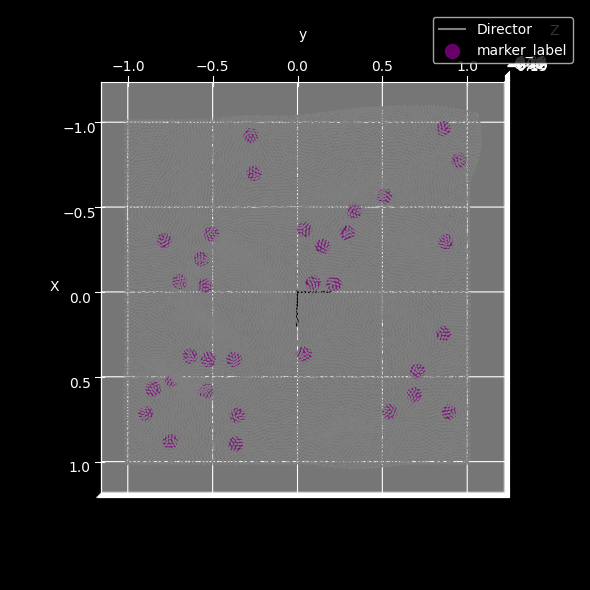

In [108]:
def unique_neighborhoods(arr):
    M, k = arr.shape
    max_index = arr.max() + 1
    membership = np.zeros((M, max_index), dtype=bool)
    membership[np.arange(M)[:, None], arr] = True
    conflict = membership @ membership.T > 0
    np.fill_diagonal(conflict, 0)
    selected = []
    remaining = np.ones(M, dtype=bool)

    while remaining.any():
        degrees = conflict[remaining][:, remaining].sum(axis=1)
        idx_in_remaining = np.argmin(degrees)
        idx = np.flatnonzero(remaining)[idx_in_remaining]
        selected.append(idx)
        to_remove = conflict[idx] | (np.arange(M) == idx)
        remaining[to_remove] = False

    return arr[selected]


k_charge = 30
defect_idxs = np.argsort(S)[:250]
test_charge_patch_idxs = analysis.coord_search_neighbours(mesh.vertices, k=k_charge)[idxs_sel][defect_idxs]
test_charge_patch_idxs, _ = analysis.filter_valid_patches(mesh.vertices, test_charge_patch_idxs, factor=0.2)
test_charge_patch_idxs = unique_neighborhoods(test_charge_patch_idxs)
defect_idxs = test_charge_patch_idxs[:, 0]
visuals.plot_dir_field(directors=random_vecfield, veclength=0.02, veccolor="grey",
                       marker=random_vecfield[:, :3][test_charge_patch_idxs[:, 0]], view_init=[90, 0],
                       pt_color="purple", pt_alpha=0.8, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

>> Calculating topological charge for 12713 directors...
>> Plotting director field...


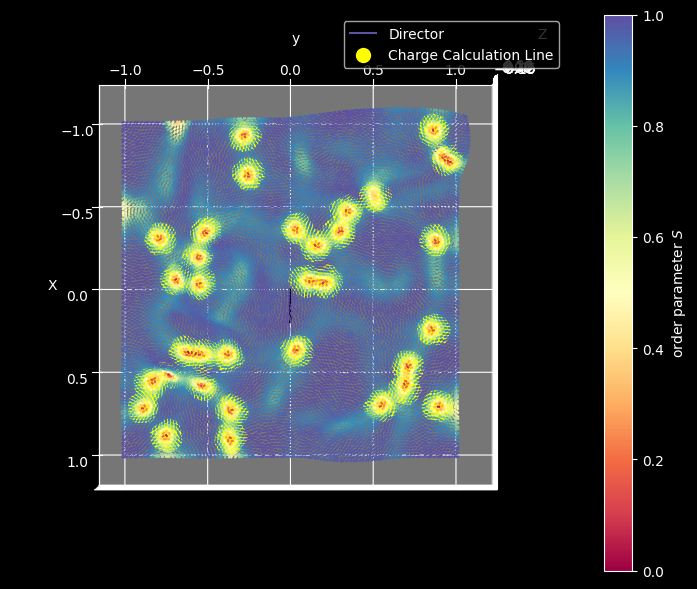

>> Plotting director field...


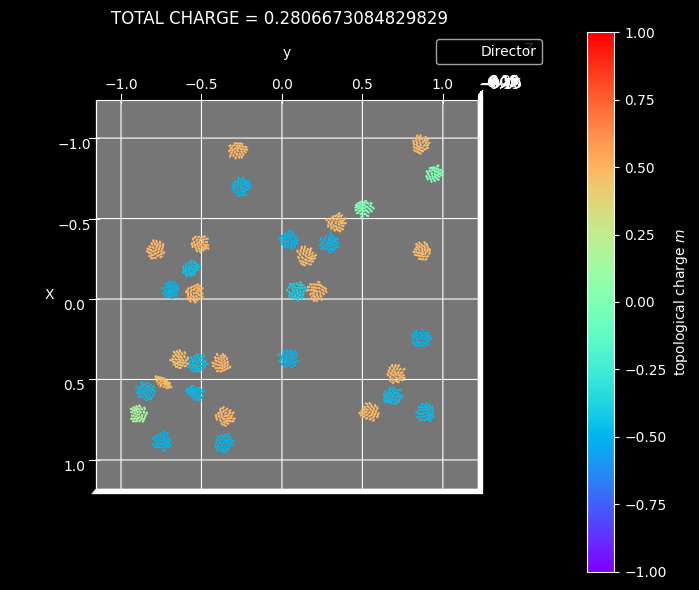

In [109]:

charge_results = analysis.curved_nem_charge(mesh=mesh, directors=random_vecfield,
                                            calc_idxs=defect_idxs,
                                            director_indeces=idxs_sel,
                                            tan_x=tan_x, tan_y=tan_y, c_gauss=C_gauss,
                                            loop_angle_precision=3, k_charge=k_charge,
                                            debug=False, return_all_contributions=True)
m_charge, calc_charge_loop_idxs, m_line_charge, m_gauss_contribution = charge_results

visuals.plot_dir_field(directors=random_vecfield, veclength=0.02, veccolor=S,
                       marker=np.vstack([mesh.vertices[i] for i in calc_charge_loop_idxs]),
                       pt_label="Charge Calculation Line", view_init=[90, 0],
                       pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

m_charge_extended = np.full(len(random_vecfield), np.nan)
m_charge_extended[test_charge_patch_idxs] = m_charge[:, np.newaxis]
m_charge_extended = m_charge_extended.ravel()

visuals.plot_dir_field(directors=random_vecfield, veclength=0.02, veccolor=m_charge_extended, cmap="rainbow",
                       title=f"TOTAL CHARGE = {np.nansum(m_charge)}",
                       view_init=[90, 0], cmap_label="topological charge $m$", manual_vminmax=[-1, 1], show_axes=False)

In [112]:
plot_m_charge_extended = m_charge_extended.copy()
plot_m_charge_extended[np.isnan(plot_m_charge_extended)] = 0.0
visuals.view_colored_mesh_dir_field(mesh=mesh, directors=random_vecfield, mesh_shading="smooth",
                                    mesh_vert_colors="grey",
                                    vec_colors=visuals.color_scalar(plot_m_charge_extended, manual_vminmax=[-1, 1],
                                                                    cmap="rainbow"),
                                    vec_length=0.02, vec_edge_width=0.003)

>> Rendering mesh and colored vertices...


In [ ]:
# low_order_idxs = np.argsort(S_order)[:10]
# target_num = 4
# dist_cutoff = 0.1
# defect_i_chosen = [0]
# dist_matrix = np.array([
#     [analysis.geodesic_distmesh(mesh, idxs_sel[idx1], idxs_sel[idx2], debug=False) for idx2 in low_order_idxs]
#     for idx1 in low_order_idxs
# ])
# print("Distance matrix was created !")
# for _ in range(1, target_num):
#     remaining = np.setdiff1d(np.arange(len(low_order_idxs)), defect_i_chosen)
#     min_distances = np.min(dist_matrix[remaining][:, defect_i_chosen], axis=1)
#     next_choice = remaining[np.argmax(min_distances)]
#     if np.all(dist_matrix[next_choice, defect_i_chosen] > dist_cutoff):
#         defect_i_chosen.append(next_choice)
# defect_idxs = [low_order_idxs[idx] for idx in defect_i_chosen]
# print(f"Found {len(defect_idxs)} defects!")


In [ ]:
k_order = 3 ** 2
L = 10
N = 20
# defects = [[0, 0, 1.0]]
dpos = L / 4
defects = [[-dpos, -dpos, 1.0], [-dpos, dpos, 0.5], [dpos, -dpos, -0.5], [dpos, dpos, -1]]
x, y, u, v = simulation.point_defect_2d_charge_multiple(l=L, n=N, defects=defects)
directors = np.column_stack(
    (x.flatten(), y.flatten(), np.zeros_like(x.flatten()), u.flatten(), v.flatten(), np.zeros_like(u.flatten())))
normals = np.zeros((directors.shape[0], 3))
normals[:, 2] = 1
mesh = trimesh.Trimesh(vertices=directors[:, :3], vertex_normals=normals,
                       faces=scipy.spatial.Delaunay(directors[:, :2]).simplices)
freq = 1
directors = directors[::freq]

idxs_sel = []
for i, vertex in enumerate(mesh.vertices):
    for j, director_pos in enumerate(directors[:, :3]):
        if np.all(vertex == director_pos):
            idxs_sel.append(i)
idxs_sel = np.array(idxs_sel)
tan_x, tan_y = analysis.create_tangential_basis(mesh.vertex_normals)

S_order, n_avg = analysis.avg_tan_nem_tens(t1_cov=tan_x[idxs_sel], t2_cov=tan_y[idxs_sel], directors=directors,
                                           neigh_idxs=analysis.coord_search_neighbours(verts=directors[:, :3],
                                                                                       k=k_order))

visuals.plot_dir_field(directors=directors, veclength=0.5, veccolor=S_order, view_init=[90, 0],
                       pt_alpha=0.8, cmap_label="order parameter $S$", manual_vminmax=[0, 1], show_axes=False)

defect_idxs = np.argsort(S_order)  #[:20]

visuals.plot_dir_field(directors=directors, veclength=0.5, veccolor=S_order,
                       marker=directors[:, :3][defect_idxs], view_init=[90, 0],
                       pt_color="purple",
                       pt_alpha=0.8, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

k_charge = 5 ** 2
test_charge_patch_idxs = analysis.coord_search_neighbours(mesh.vertices, k=k_charge)[idxs_sel][defect_idxs]
test_charge_patch_idxs, _ = analysis.filter_valid_patches(mesh.vertices, test_charge_patch_idxs, factor=0.01)

visuals.plot_dir_field(directors=directors, veclength=0.5, veccolor=S_order,
                       marker=directors[:, :3][test_charge_patch_idxs[:, 0]], view_init=[90, 0],
                       pt_color="purple",
                       pt_alpha=0.8, cmap_label="order parameter $S$", manual_vminmax=[0, 1])


def unique_neighborhoods(arr):
    M, k = arr.shape
    max_index = arr.max() + 1
    membership = np.zeros((M, max_index), dtype=bool)
    membership[np.arange(M)[:, None], arr] = True
    conflict = membership @ membership.T > 0
    np.fill_diagonal(conflict, 0)
    selected = []
    remaining = np.ones(M, dtype=bool)

    while remaining.any():
        degrees = conflict[remaining][:, remaining].sum(axis=1)
        idx_in_remaining = np.argmin(degrees)
        idx = np.flatnonzero(remaining)[idx_in_remaining]
        selected.append(idx)
        to_remove = conflict[idx] | (np.arange(M) == idx)
        remaining[to_remove] = False

    return arr[selected]


test_charge_patch_idxs = unique_neighborhoods(test_charge_patch_idxs)
defect_idxs = test_charge_patch_idxs[:, 0]

visuals.plot_dir_field(directors=directors, veclength=0.5, veccolor=S_order,
                       marker=directors[:, :3][defect_idxs], view_init=[90, 0],
                       pt_color="purple",
                       pt_alpha=0.8, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

k_gauss = 3 ** 2
C_gauss, _, C_gauss_idxs, _ = analysis.curvature_by_srf_fit(mesh=mesh, k=k_gauss, debug=False,
                                                            gauss_crop_range=None, num_sample=1000)
charge_results = analysis.curved_nem_charge(mesh=mesh, directors=directors,
                                            calc_idxs=defect_idxs,
                                            director_indeces=idxs_sel,
                                            tan_x=tan_x, tan_y=tan_y, c_gauss=C_gauss,
                                            loop_angle_precision=3, k_charge=k_charge,
                                            debug=False, return_all_contributions=True)
m_charge, calc_charge_loop_idxs, m_line_charge, m_gauss_contribution = charge_results

visuals.plot_dir_field(directors=directors, veclength=0.5, veccolor=S_order,
                       marker=np.vstack([mesh.vertices[i] for i in calc_charge_loop_idxs]),
                       pt_label="Charge Calculation Line", view_init=[90, 0],
                       pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1])
# visuals.plot_dir_field(directors=directors, veclength=0.5, veccolor=S_order,
#                        marker=mesh.vertices[calc_charge_loop_idxs[0]],
#                        pt_label="Charge Calculation Line", view_init=[90, 0],
#                        pt_color=visuals.color_scalar(np.linspace(0, 1, calc_charge_loop_idxs[0].shape[0]),
#                                                      cmap="Blues"),
#                        pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

visuals.plot_hist(m_charge, title="Defect Topological Charge")
visuals.plot_dir_field(directors=directors[defect_idxs], veclength=0.5, veccolor=m_charge, cmap="rainbow",
                       view_init=[90, 0], cmap_label="topological charge $m$", manual_vminmax=[-1, 1], show_axes=False)

m_charge_extended = np.full(len(directors), np.nan)
m_charge_extended[test_charge_patch_idxs] = m_charge[:, np.newaxis]
m_charge_extended = m_charge_extended.ravel()

visuals.plot_dir_field(directors=directors, veclength=0.5, veccolor=m_charge_extended, cmap="rainbow",
                       title=f"TOTAL CHARGE = {np.nansum(m_charge)}",
                       view_init=[90, 0], cmap_label="topological charge $m$", manual_vminmax=[-1, 1], show_axes=False)

In [ ]:
# Simulate data with multiple defects
L = 10
N = 40
dpos = L / 2
defects = [[-dpos, -dpos, 1.0], [-dpos, dpos, 0.5], [dpos, -dpos, -0.5], [dpos, dpos, -1]]
x, y, u, v = simulation.point_defect_2d_charge_multiple(l=L, n=N, defects=defects)

# Flatten and normalize grid to fit in unit square [-1, 1]
xy_flat = np.column_stack((x.flatten(), y.flatten()))
xy_norm = (xy_flat - xy_flat.mean(axis=0)) / (xy_flat.max() - xy_flat.min()) * 2
X, Y = xy_norm[:, 0], xy_norm[:, 1]

# Select only points inside the unit disk (i.e., the base of the hemisphere)
inside_mask = X ** 2 + Y ** 2 <= 1.0
X_inside = X[inside_mask]
Y_inside = Y[inside_mask]
Z_inside = np.sqrt(np.clip(1 - X_inside ** 2 - Y_inside ** 2, 0, 1))

# Projected 3D positions on hemisphere
projected_points = np.column_stack((X_inside, Y_inside, Z_inside))

# Triangulate using only 2D (X,Y) positions inside the unit circle
xy_inside = np.column_stack((X_inside, Y_inside))
tri = scipy.spatial.Delaunay(xy_inside)

# Create the mesh with projected points and faces
mesh = trimesh.Trimesh(vertices=projected_points,
                       faces=tri.simplices,
                       vertex_normals=projected_points)  # normals = positions on unit sphere

# Project u, v into 3D using the tangent basis
u_flat = u.flatten()[inside_mask]
v_flat = v.flatten()[inside_mask]

# Create tangent basis for each vertex on the hemisphere
tan_x, tan_y = analysis.create_tangential_basis(mesh.vertex_normals)

# Construct director vectors in 3D
director_vecs = u_flat[:, None] * tan_x + v_flat[:, None] * tan_y

# Combine position and director into final data
directors = np.hstack((projected_points, director_vecs))

# Compute nematic order parameter
k_order = 9  # 3**2
neigh_idxs = analysis.coord_search_neighbours(verts=projected_points, k=k_order)
S_order, n_avg = analysis.avg_tan_nem_tens(
    t1_cov=tan_x, t2_cov=tan_y, directors=directors, neigh_idxs=neigh_idxs
)

# Plot the director field with color-coded order parameter
visuals.plot_dir_field(
    directors=directors,
    veclength=0.1,
    veccolor=S_order,
    view_init=[45, 0],
    pt_alpha=0.8,
    cmap_label="order parameter $S$",
    manual_vminmax=[0, 1],
    show_axes=False
)
idxs_sel = np.arange(mesh.vertices.shape[0])

In [ ]:

defect_idxs = np.argsort(S_order)  #[:8]

visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order,
                       marker=directors[:, :3][defect_idxs], view_init=[45, 0],
                       pt_color="purple",
                       pt_alpha=0.8, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

k_charge = 35
test_charge_patch_idxs = analysis.coord_search_neighbours(mesh.vertices, k=k_charge)[idxs_sel][defect_idxs]
test_charge_patch_idxs = test_charge_patch_idxs[np.argsort(S_order[:20])]
test_charge_patch_idxs, _ = analysis.filter_valid_patches(mesh.vertices, test_charge_patch_idxs, factor=0.2)
visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order,
                       marker=directors[:, :3][test_charge_patch_idxs[:, 0]], view_init=[45, 0],
                       pt_color="purple",
                       pt_alpha=0.8, cmap_label="order parameter $S$", manual_vminmax=[0, 1])
if True:
    def unique_neighborhoods(arr):
        M, k = arr.shape
        max_index = arr.max() + 1
        membership = np.zeros((M, max_index), dtype=bool)
        membership[np.arange(M)[:, None], arr] = True
        conflict = membership @ membership.T > 0
        np.fill_diagonal(conflict, 0)
        selected = []
        remaining = np.ones(M, dtype=bool)

        while remaining.any():
            degrees = conflict[remaining][:, remaining].sum(axis=1)
            idx_in_remaining = np.argmin(degrees)
            idx = np.flatnonzero(remaining)[idx_in_remaining]
            selected.append(idx)
            to_remove = conflict[idx] | (np.arange(M) == idx)
            remaining[to_remove] = False

        return arr[selected]


    test_charge_patch_idxs = unique_neighborhoods(test_charge_patch_idxs)
    defect_idxs = test_charge_patch_idxs[:, 0]

    visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order,
                           marker=directors[:, :3][defect_idxs], view_init=[45, 0],
                           pt_color="purple",
                           pt_alpha=0.8, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

    k_gauss = 3 ** 2
    C_gauss, _, C_gauss_idxs, _ = analysis.curvature_by_srf_fit(mesh=mesh, k=k_gauss, debug=False,
                                                                gauss_crop_range=[0.9, 1.1], num_sample=1000)

    uncalc_c_gauss = np.setdiff1d(np.arange(mesh.vertices.shape[0]), C_gauss_idxs)
    full_C_gauss = np.full(mesh.vertices.shape[0], np.nan)
    full_C_gauss[C_gauss_idxs] = C_gauss
    idxs = analysis.coord_search_neighbours(mesh.vertices, k=100)
    full_C_gauss[uncalc_c_gauss] = np.nanmean(full_C_gauss[idxs[uncalc_c_gauss]], axis=1)
    print(f"Number of nans in Gauss: {np.isnan(full_C_gauss).sum()}")
    C_gauss = full_C_gauss
    print(C_gauss.min(), C_gauss.max(), C_gauss.mean())
    charge_results = analysis.curved_nem_charge(mesh=mesh, directors=directors,
                                                calc_idxs=defect_idxs,
                                                director_indeces=idxs_sel,
                                                tan_x=tan_x, tan_y=tan_y, c_gauss=C_gauss,
                                                loop_angle_precision=1, k_charge=k_charge,
                                                debug=False, return_all_contributions=True)
    m_charge, calc_charge_loop_idxs, m_line_charge, m_gauss_contribution = charge_results

    visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order,
                           marker=np.vstack([mesh.vertices[i] for i in calc_charge_loop_idxs]),
                           pt_label="Charge Calculation Line", view_init=[45, 0],
                           pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1])
    # visuals.plot_dir_field(directors=directors, veclength=0.2, veccolor=S_order,
    #                        marker=mesh.vertices[calc_charge_loop_idxs[0]],
    #                        pt_label="Charge Calculation Line", view_init=[45, 0],
    #                        pt_color=visuals.color_scalar(np.linspace(0, 1, calc_charge_loop_idxs[0].shape[0]),
    #                                                      cmap="Blues"),
    #                        pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

    visuals.plot_hist(m_charge, title="Defect Topological Charge")
    visuals.plot_dir_field(directors=directors[defect_idxs], veclength=0.1, veccolor=m_charge, cmap="rainbow",
                           view_init=[45, 0], cmap_label="topological charge $m$", manual_vminmax=[-1, 1],
                           show_axes=False)

    m_charge_extended = np.full(len(directors), np.nan)
    m_charge_extended[test_charge_patch_idxs] = m_charge[:, np.newaxis]
    m_charge_extended = m_charge_extended.ravel()

    visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=m_charge_extended, cmap="rainbow",
                           title=f"TOTAL CHARGE = {np.nansum(m_charge)}",
                           view_init=[45, 0], cmap_label="topological charge $m$", manual_vminmax=[-1, 1],
                           show_axes=False)

In [ ]:
m_range = np.arange(-1, 1 + 0.125, 0.125)
k_charge_range = np.arange(10, len(mesh.vertices), 100)
k_charge_range = [200]
m_exp = []
m_res = []
k_charge_ = []
for m in m_range:
    for k_charge in k_charge_range:
        defects = [[0, 0, m]]
        x, y, u, v = simulation.point_defect_2d_charge_multiple(l=2,
                                                                n=31, defects=defects)
        directors = np.column_stack(
            (
                x.flatten(), y.flatten(), np.zeros_like(x.flatten()), u.flatten(), v.flatten(),
                np.zeros_like(u.flatten())))
        normals = np.zeros((directors.shape[0], 3))
        normals[:, 2] = 1
        mesh = trimesh.Trimesh(vertices=directors[:, :3], vertex_normals=normals,
                               faces=scipy.spatial.Delaunay(directors[:, :2]).simplices)
        tan_x, tan_y = analysis.create_tangential_basis(mesh.vertex_normals)
        # visuals.plot_dir_field(directors=directors, veclength=0.1, view_init=[-90, 0])
        # visuals.plot_dir_field(directors=directors, normals=mesh.vertex_normals, veclength=0.2)
        # visuals.view_mesh_dir_field(mesh_list=[mesh], directors=directors,
        #                                    vec_length=0.1, vec_colors="red")
        S_order, n_avg = analysis.avg_tan_nem_tens(t1_cov=tan_x, t2_cov=tan_y, directors=directors,
                                                   neigh_idxs=analysis.coord_search_neighbours(verts=directors[:, :3],
                                                                                               k=k_order))
        # visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order, cmap_label="order parameter $S$",
        #                        manual_vminmax=[0, 1], view_init=[90, 0])
        low_order_idxs = np.argsort(S_order)
        # low_order_idxs = [480]
        # visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order,
        #                        marker=directors[:, :3][low_order_idxs], pt_label="Defect Locations",
        #                        pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1], view_init=[90, 0])

        k_gauss = 20
        C_gauss, _, C_gauss_idxs, _ = analysis.curvature_by_srf_fit(mesh=mesh, k=k_gauss, debug=False,
                                                                    gauss_crop_range=None, num_sample=1000)
        charge_results = analysis.curved_nem_charge(mesh=mesh, directors=directors,
                                                    calc_idxs=low_order_idxs,
                                                    director_indeces=np.arange(
                                                        mesh.vertices.shape[0]),
                                                    tan_x=tan_x, tan_y=tan_y, c_gauss=C_gauss,
                                                    loop_angle_precision=1, k_charge=k_charge,
                                                    debug=False, return_all_contributions=True)
        m_charge, calc_charge_loop_idxs, m_line_charge, m_gauss_contribution = charge_results
        print(f"k={k_charge} | FOUND {m_charge[~np.isnan(m_charge)]}")
        # visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order,
        #                        marker=directors[:, :3][calc_charge_loop_idxs[0]],
        #                        pt_label="Charge Calculation Line", view_init=[90, 0],
        #                        pt_color=visuals.color_scalar(np.linspace(0, 1, calc_charge_loop_idxs[0].shape[0]),
        #                                                      cmap="Blues"),
        #                        pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1])

        # visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=m_charge, cmap="rainbow",
        #                cmap_label="topological charge $m$", manual_vminmax=[-1, 1], view_init=[90, 0], savefig=f"/Users/andreadi/Downloads/m-{m}_k-{k_charge}.png")
        if m > 0:
            m_res.append(np.nanmax(m_charge))
        else:
            m_res.append(np.nanmin(m_charge))
        m_exp.append(m)
        k_charge_.append(k_charge)
        break
m_res = np.array(m_res)
m_exp = np.array(m_exp)
k_charge_ = np.array(k_charge_)
plt.figure()
colormap = plt.cm.Spectral
for idx, sel_k_charge in enumerate(np.unique(k_charge_)):
    select_k = k_charge_ == sel_k_charge
    color = colormap(idx / len(np.unique(k_charge_)))
    plt.plot(m_exp[select_k], m_res[select_k], "o-", label=f"k={sel_k_charge}", color=color)
plt.plot(m_range, m_range, "--", c="grey")
plt.xlabel("Expected topological charge")
plt.ylabel("Calculated topological charge")
plt.legend()
plt.show()

In [ ]:
# mesh = trimesh.creation.icosphere(radius=1, subdivisions=3)
# visuals.plot_maxproj_pts(mesh.vertices, cmap="Greys", unit="??", hexsize=100)
# mesh = trimesh.creation.uv_sphere(radius=1, subdivisions=5)
mesh = trimesh.creation.icosphere(radius=1, subdivisions=4)
mesh_sel_mask = np.einsum('ij,ij->i', np.array([[0, 0, -1] for i in range(len(mesh.vertices))]),
                          mesh.vertex_normals) < 0
mesh = analysis.sel_submesh(mesh=mesh, mask=mesh_sel_mask)
x, y, z = mesh.vertices.T
r = np.linalg.norm(mesh.vertices, axis=1)
theta = np.arccos(z / r)
phi = np.arctan2(y, x)

# RING
t1_x = -np.sin(phi)
t1_y = np.cos(phi)
t1_z = np.zeros_like(t1_x)

# ASTER
t1_x = np.cos(phi) * np.cos(theta)
t1_y = np.sin(phi) * np.cos(theta)
t1_z = -np.sin(theta)

# Vortex field
# t1_x = -np.sin(phi) * np.cos(theta)  # Tangential in azimuthal direction
# t1_y = np.cos(phi) * np.cos(theta)  # Tangential in azimuthal direction
# t1_z = -np.sin(theta)

# =======# =======# =======# =======# =======# =======
# m = 2.0  # desired topological charge
#
# # Basis vectors (tangent to sphere)
# e_theta_x = np.cos(theta) * np.cos(phi)
# e_theta_y = np.cos(theta) * np.sin(phi)
# e_theta_z = -np.sin(theta)
#
# e_phi_x = -np.sin(phi)
# e_phi_y = np.cos(phi)
# e_phi_z = np.zeros_like(phi)
#
# # Director field components: v = cos(mφ)·e_θ + sin(mφ)·e_φ
# m -= 1
# t1_x = np.cos(m * phi) * e_theta_x + np.sin(m * phi) * e_phi_x
# t1_y = np.cos(m * phi) * e_theta_y + np.sin(m * phi) * e_phi_y
# t1_z = np.cos(m * phi) * e_theta_z + np.sin(m * phi) * e_phi_z
# =======# =======# =======# =======# =======# =======

directors = np.column_stack((mesh.vertices, t1_x, t1_y, t1_z))
directors[:, 3:] /= np.linalg.norm(directors[:, 3:], axis=1, keepdims=True)

# mesh.vertices[:, 2] = 0
# directors[:, 2] = 0
# directors[:, 5] = 0
# directors[:, 3:] /= np.linalg.norm(directors[:, 3:], axis=1, keepdims=True)

tan_x, tan_y = analysis.create_tangential_basis(mesh.vertex_normals)
visuals.plot_dir_field(directors=directors, veclength=0.1)
visuals.plot_dir_field(directors=directors, normals=mesh.vertex_normals, veclength=0.2)
# visuals.view_mesh_and_vector_field(mesh_list=[mesh], directors=directors,
#                                    vec_length=0.1, vec_colors="red")

In [ ]:
k_order = 3
k_gauss = 20
# k_charge = 50  #len(mesh.vertices)
k_charge_range = np.linspace(50, len(mesh.vertices), 10)
# k_charge_range = [len(mesh.vertices)]
k_charges_ = []
m_charges_ = []
gauss_contributions_ = []
line_contributions_ = []

S_order, n_avg = analysis.avg_tan_nem_tens(t1_cov=tan_x, t2_cov=tan_y, directors=directors,
                                           neigh_idxs=analysis.coord_search_neighbours(verts=mesh.vertices,
                                                                                       k=k_order))
low_order_idxs = np.argsort(S_order)[:1]
for k_charge in k_charge_range:
    C_gauss, _, C_gauss_idxs, _ = analysis.curvature_by_srf_fit(mesh=mesh, k=k_gauss, debug=False,
                                                                gauss_crop_range=None, num_sample=len(mesh.vertices))
    charge_results = analysis.curved_nem_charge(mesh=mesh, directors=directors,
                                                calc_idxs=low_order_idxs,
                                                director_indeces=np.arange(
                                                    mesh.vertices.shape[0]),
                                                tan_x=tan_x, tan_y=tan_y, c_gauss=C_gauss,
                                                loop_angle_precision=1, k_charge=k_charge,
                                                debug=False, return_all_contributions=True)
    m_charge, calc_charge_loop_idxs, m_line_charge, m_gauss_contribution = charge_results
    print(f"k={k_charge} | FOUND {m_charge[~np.isnan(m_charge)]}")
    k_charges_.append(k_charge)
    m_charges_.append([np.nanmean(m_charge[~np.isnan(m_charge)]),
                       np.nanstd(m_charge[~np.isnan(m_charge)]) / np.sum(~np.isnan(m_charge))])
    gauss_contributions_.append(
        [np.nanmean(m_gauss_contribution), np.nanstd(m_gauss_contribution) / np.sum(~np.isnan(m_gauss_contribution))])
    line_contributions_.append([np.nanmean(m_line_charge), np.nanstd(m_line_charge) / np.sum(~np.isnan(m_line_charge))])
    # visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=S_order,
    #                        marker=directors[:, :3][low_order_idxs], pt_label="Defect Locations",
    #                        pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1])
    # visuals.plot_hist(m_charge[~np.isnan(m_charge)], title="Defect Topological Charge")
    # visuals.plot_dir_field(directors=directors[:1], veclength=0.1, veccolor=S_order,
    #                        marker=directors[:, :3][calc_charge_loop_idxs[0]],
    #                        pt_label="Charge Calculation Line",
    #                        pt_color=visuals.color_scalar(np.linspace(0, 1, calc_charge_loop_idxs[0].shape[0]),
    #                                                      cmap="Blues"),
    #                        pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1])
    # visuals.plot_dir_field(directors=directors, veclength=0.1, veccolor=m_charge, cmap="rainbow",
    #                        cmap_label="topological charge $m$", manual_vminmax=[-1, 1])
    # inter_defect_dist = analysis.geodesic_distmesh(mesh=mesh, index1=low_order_idxs[0], index2=low_order_idxs[1],
    #                                                debug=True)
    # visuals.view_mesh_dir_field(mesh_list=[mesh], directors=directors,
    #                             vec_colors=visuals.color_scalar(m_charge, cmap="hsv", manual_vminmax=[-1, 1]),
    #                             vec_length=0.1)
m_charges_ = np.array(m_charges_)
gauss_contributions_ = np.array(gauss_contributions_)
line_contributions_ = np.array(line_contributions_)

polar_angles = np.linspace(0, 1, len(gauss_contributions_)) * np.pi / 2
gauss_contribution = 1 - np.cos(polar_angles)
plt.figure()
plt.axhline(1.0, linestyle='--', color='white', label="Expected")
plt.plot(np.degrees(polar_angles), gauss_contributions_[:, 0], "o-", c="red", label="Gauss Surface Integral")
plt.errorbar(np.degrees(polar_angles), gauss_contributions_[:, 0], yerr=gauss_contributions_[:, 1], fmt="o", c="red",
             capsize=2)
plt.plot(np.degrees(polar_angles), line_contributions_[:, 0], "o-", c="blue", label="Line Integral")
plt.errorbar(np.degrees(polar_angles), line_contributions_[:, 0], yerr=line_contributions_[:, 1], fmt="o", c="blue",
             capsize=2)
plt.plot(np.degrees(polar_angles), m_charges_[:, 0], "o-", c="yellow", label="Total")
plt.errorbar(np.degrees(polar_angles), m_charges_[:, 0], yerr=m_charges_[:, 1], fmt="o",
             c="yellow", capsize=2)
plt.grid()
plt.legend()
plt.show()

In [ ]:
# visuals.view_mesh_dir_field(mesh_list=[mesh], directors=directors, vec_colors=visuals.color_scalar(S_order),
#                                    vec_length=0.1, verts=directors[:, :3][low_order_idxs], verts_colors="yellow")
# visuals.view_mesh_dir_field(mesh_list=[mesh], directors=directors,
#                             vec_colors=visuals.color_scalar(m_charge, cmap="hsv", manual_vminmax=[-1, 1]),
#                             vec_length=0.1)

In [ ]:
# control_folder = '/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/3_simulated/saddle-surface/data/1-defect/'
# control_directors = datahandler.load_array(name="directors", folderpath=control_folder)
# control_tan_x = datahandler.load_array(name="tan_x", folderpath=control_folder)
# control_tan_y = datahandler.load_array(name="tan_y", folderpath=control_folder)
# control_normals = np.cross(control_tan_x, control_tan_y)
# visuals.plot_dir_field(directors=control_directors, normals=control_normals, veclength=0.03)
# control_mesh = trimesh.Trimesh(vertices=control_directors[:, :3], vertex_normals=control_normals,
#                                faces=scipy.spatial.Delaunay(control_directors[:, :2]).simplices)



# 3D Charge

In [ ]:
L = 10
N = 12
x = y = z = np.linspace(-L, L, N)
xx, yy, zz = np.meshgrid(x, y, z)
center = np.array([0.0, 0.0, 0.0])
test_pos = np.stack((xx.ravel(), yy.ravel(), zz.ravel()), axis=-1)
test_pos_shifted = test_pos - center
test_dir = -test_pos_shifted / (np.linalg.norm(test_pos_shifted, axis=1, keepdims=True) + 1e-6)
test_dir = test_dir / (np.linalg.norm(test_dir, axis=1, keepdims=True) + 1e-8)
test_field = np.column_stack((test_pos, test_dir))
visuals.plot_dir_field(test_field, veclength=1)
# visuals.view_3d_vector_field(vec_pos=test_field[:, :3], vec_dir=test_field[:, 3:], vec_colors="white")

In [ ]:
from scipy.spatial import KDTree


def fast_interpolate(tree, vectors, query_pts, k=8):
    dists, idxs = tree.query(query_pts, k=k)
    weights = 1 / (dists + 1e-12)
    weights /= weights.sum(axis=1, keepdims=True)
    interpolated = np.einsum('ij,ijk->ik', weights, vectors[idxs])
    return interpolated


def top_charge_bulk(field_data, idx_list, r=1.0, n_angles=10):
    points = field_data[:, :3]
    vectors = field_data[:, 3:]
    tree = KDTree(points)

    # Sphere sampling
    theta = np.linspace(0, np.pi, n_angles)
    phi = np.linspace(0, 2 * np.pi, n_angles * 2)
    theta_grid, phi_grid = np.meshgrid(theta, phi, indexing='ij')

    dtheta = theta[1] - theta[0]
    dphi = phi[1] - phi[0]
    sin_theta = np.sin(theta_grid)
    weights = sin_theta * dtheta * dphi

    sph_dx = np.sin(theta_grid) * np.cos(phi_grid)
    sph_dy = np.sin(theta_grid) * np.sin(phi_grid)
    sph_dz = np.cos(theta_grid)
    sphere_offsets = np.stack([sph_dx, sph_dy, sph_dz], axis=-1) * r
    sphere_offsets_flat = sphere_offsets.reshape(-1, 3)

    charges = np.zeros(len(idx_list))

    for j, i in enumerate(idx_list):
        center = points[i]
        sphere_points = center + sphere_offsets_flat

        interp_vectors = fast_interpolate(tree, vectors, sphere_points)
        field_on_sphere = interp_vectors.reshape(n_angles, n_angles * 2, 3)

        # Normalize
        norms = np.linalg.norm(field_on_sphere, axis=-1, keepdims=True)
        n_vecs = field_on_sphere / (norms + 1e-12)

        # Derivatives
        dn_dtheta = np.gradient(n_vecs, dtheta, axis=0)
        dn_dphi = np.gradient(n_vecs, dphi, axis=1)

        # Cross and integrand
        cross = np.cross(dn_dtheta, dn_dphi)
        integrand = np.einsum('ijk,ijk->ij', n_vecs, cross)

        charges[j] = np.sum(integrand * weights) / (4 * np.pi)

    return charges


top_charge_bulk(test_field, idx_list=[np.argmin(np.linalg.norm(test_field[:, :3], axis=1))], r=L / 2,
                n_angles=20)

In [ ]:
test = top_charge_bulk(test_field, idx_list=np.arange(len(test_field)), r=L / 2, n_angles=30)
visuals.plot_hist(test[test > 0.1])
low_order_i = np.argmax(test)
visuals.plot_dir_field(test_field, veclength=1, veccolor=test, cmap="rainbow",
                       cmap_label="Point Defect Charge", manual_vminmax=[-1, 1])

# Fusing

In [ ]:
img_path_1 = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/20250213_2p_actin-nuclei/1/d5_4_actin.tif"
img_raw_1, img_dim_1, img_scale_1, img_unit_1 = analysis.load_img(path=img_path_1, norm_vals=True, reduce_xy=1,
                                                                  reduce_z=1)
img_path_2 = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/20250213_2p_actin-nuclei/1/d5_6_actin.tif"
img_raw_2, img_dim_2, img_scale_2, img_unit_2 = analysis.load_img(path=img_path_2, norm_vals=True, reduce_xy=1,
                                                                  reduce_z=1)
img_raw_2 = np.flip(img_raw_2, axis=2)
img_raw_1 = img_raw_1[:-1]
if img_scale_1 != img_scale_2 or img_unit_1 != img_unit_2:
    print(">> Check: Unequal scaling and/or unit !!")
    img_scale, img_unit = None, None
else:
    img_scale, img_unit = img_scale_1, img_unit_1
    print(">> Check: All good to fuse !")
    visuals.plot_img(img_raw_1, scale=img_scale, unit=img_unit, cmap="Blues_r")
    visuals.plot_img(img_raw_2, scale=img_scale, unit=img_unit, cmap="Greens_r")
fused_image = np.maximum(img_cropped_1, img_flipped_2)
visuals.plot_img(fused_image, scale=img_scale, unit=img_unit, cmap="Spectral")

from scipy import ndimage

img_flipped_rotated_2 = ndimage.rotate(img_flipped_2, -3, reshape=False, axes=(2, 1))
fused_image = np.maximum(img_cropped_1, img_flipped_rotated_2)
visuals.plot_img(img_cropped_1, scale=img_scale, unit=img_unit, cmap="Greys_r",
                 thresh_mask=analysis.thresh_img(img_flipped_rotated_2, analysis.yen_thresh(img_flipped_rotated_2[0])))
visuals.view_img(img_list=[img_raw_1, img_flipped_rotated_2], color_list=["green", "white"], opacity_list=[0.8, 0.8],
                 scale=img_scale)

# Curvature

In [ ]:
radius = 10
# mesh = trimesh.creation.icosphere(radius=radius, subdivisions=5)
# mesh = trimesh.creation.uv_sphere(radius=radius)
# mesh = trimesh.creation.capsule(radius=radius, height=radius)
# mesh = trimesh.creation.cone(radius=radius, height=radius)
# mesh = trimesh.creation.cylinder(radius=radius, height=3 * radius)
# mesh = trimesh.creation.capsule(radius=radius, height=3 * radius)
mesh = datahandler.load_mesh("/Users/andreadi/Downloads/nemo.ply", recalc_normals=True)
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Model/Meshes/tetrahedon.ply"
# path = "/Users/andreadi/Downloads/untitled.ply"
# path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/2_organoid/Position 1_Settings 1_fused/data/full_mesh_smooth.ply"
# path = '/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/clean_multi-layer/ellipsoid_mx_main_clean/data/mesh_smooth.ply'

# path = "/Users/andreadi/Downloads/t0.ply"
# mesh = datahandler.load_mesh(path, recalc_normals=True)
# mesh = analysis.simplify_mesh(mesh, target_face_count=100000)
# mesh = analysis.subdivide_mesh(mesh, max_edge=0.4)

# mesh = analysis.simplify_mesh(mesh, remove_percent=0.5)
# mesh = analysis.smoothen_mesh(mesh, 300)

# visuals.view_mesh([mesh], hide_vectors=True)
# visuals.plot_maxproj_pts(mesh.vertices, cmap="Greys_r", unit="?")
# visuals.plot_dir_field(np.column_stack((mesh.vertices, mesh.vertex_normals)), normals=mesh.vertex_normals,
#                        aspect="auto", veclength=1, freq=10)

print(f"Gauss should be around {1 / np.ptp(mesh.vertices, axis=0).mean() ** 2:.3e}, "
      f"Mean should be around {1 / np.ptp(mesh.vertices, axis=0).mean():.3e}")
C_gauss, C_mean, C_gauss_idxs, C_mean_idxs = analysis.curvature_by_srf_fit(mesh, k=50, debug=True,
                                                                           gauss_crop_range=None,
                                                                           mean_crop_range=None, num_sample=10000)
visuals.plot_hist(C_gauss, title="Gauss")
visuals.plot_hist(C_mean, title="Mean")
visuals.view_mesh_and_verts(mesh_list=[mesh], verts=mesh.vertices[C_gauss_idxs],
                            verts_colors=visuals.color_scalar(C_gauss), verts_size=0.4, use_orig_color=True,
                            mesh_colors="white")

visuals.plot_maxproj_pts(verts=mesh.vertices[C_mean_idxs], unit="?",
                         colors=analysis.normalise_range(C_mean), hexsize=100)
visuals.plot_maxproj_pts(verts=mesh.vertices[C_gauss_idxs], unit="?",
                         colors=analysis.normalise_range(C_gauss), hexsize=100)

In [ ]:

# visuals.view_mesh_and_verts(mesh_list=[mesh], verts=mesh.vertices[C_gauss_idxs],
#                             verts_colors=visuals.color_scalar(C_gauss), verts_size=1,
#                             use_orig_color=True,
#                             mesh_colors="white")
visuals.view_mesh_and_verts(mesh_list=[mesh], verts=mesh.vertices[C_mean_idxs],
                            verts_colors=visuals.color_scalar(C_mean), verts_size=1,
                            use_orig_color=True,
                            mesh_colors="white")

In [ ]:
radii = np.linspace(1, 10, 10)
C_gauss_all = []
C_mean_all = []
radii_all = []
for radius in radii:
    mesh = trimesh.creation.icosphere(radius=radius, subdivisions=4)
C_gauss, C_mean, _, _ = analysis.curvature_by_srf_fit(mesh, k=50, num_sample=10000)
C_gauss_all.append(C_gauss)
C_mean_all.append(C_mean)
radii_all.append(radius)

radii_all = np.asarray(radii_all)
C_gauss_all = np.asarray(C_gauss_all)
C_mean_all = np.asarray(C_mean_all)
C_gauss_avg = np.average(C_gauss_all, axis=1)
C_mean_avg = np.average(C_mean_all, axis=1)

C_gauss_expected = 1 / radii_all ** 2
C_mean_expected = 1 / radii_all
fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True)
ax[0].plot(radii_all, C_gauss_avg, "x", label="Measured $C_{Gauss}$")
ax[0].plot(radii_all, C_gauss_expected, "--", label="Expected")
ax[1].plot(radii_all, C_mean_avg, "x", label="Measured $C_{Mean}$")
ax[1].plot(radii_all, C_mean_expected, "--", label="Expected")
ax[0].set_ylim(0, 1.2)
ax[1].set_ylim(0, 1.2)
ax[1].set_xlabel("Radius")
ax[0].legend()
ax[1].legend()
plt.show()

fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True)
ax[0].plot(radii_all, (C_gauss_avg - C_gauss_expected) / C_gauss_expected ** 2, "x", label="$C_{Gauss}$ Relative Error")
ax[1].plot(radii_all, (C_mean_avg - C_mean_expected) / C_mean_expected, "x", label="$C_{Mean}$ Relative Error")
ax[1].set_xlabel("Radius")
ax[0].legend()
ax[1].legend()

# Geodesic Distance on Mesh

In [ ]:
mesh = trimesh.creation.icosphere(radius=1, subdivisions=4)
index1 = np.argwhere(mesh.vertices[:, 0] == mesh.vertices[:, 0].min())[0][0]
index2 = np.argwhere(mesh.vertices[:, 0] == mesh.vertices[:, 0].max())[0][0]
analysis.geodesic_distmesh(mesh, index1, index2, debug=True)
visuals.plot_dir_field(directors=np.column_stack((mesh.vertices, mesh.vertices)), veclength=0.1,
                       veccolor="red",
                       marker=mesh.vertices[[index1, index2]],
                       pt_label="Points",
                       pt_alpha=1.0, cmap_label="order parameter $S$")

In [ ]:
# img = np.zeros(shape=(100, 100))
# figsize = (10, 10)
# boxsize = 2
# mask_thresh_val = 0.3
# nem_analysis_neigh_num = 3 ** 3
# x, y = np.meshgrid(range(len(img)), range(len(img)))
# img[abs(np.sqrt((x - len(img) // 2) ** 2 + (y - len(img) // 2) ** 2) - 20) < 1] = 1
# img = analysis.gaussian_blur(img, sigma=2, renorm=False)
# visuals.plot_matrix(img, aspect=1, cmap='Greys_r', colorbar=True, title='Intensity Profile')
# orient2d_results = analysis.orient2d(img=img, boxsize=boxsize,
#                                      thresh_val=mask_thresh_val,
#                                      num_neigh_nem=nem_analysis_neigh_num, log_debug=False)
# theta_all_deg, theta_masked_rad, S_2d, n_2d, X, Y = orient2d_results
# visuals.plot_matrix(theta_all_deg, aspect=1, cmap='twilight', colorbar=True,
#                     title=f'Theta Angles for block {boxsize}x{boxsize}')
# visuals.plot_polar_hist(angles_deg=theta_all_deg)
# visuals.plot_matrix_vectors(Y, X, theta_masked_rad.T, img, title="Intensity Profile + Directors",
#                             veclength=0.1, vescale=300, vec_colors=S_2d,
#                             cbar_matrix_label="Intensity Signal (a.u.)", cbar_vector_label="order parameter $S$")
# visuals.plot_hist(array=S_2d, title="order parameter $S$")
# # visuals.plot_polar_hist(angles_deg=np.linspace(-90, 90, 30))

In [ ]:
# vec_posdir = np.array([[0, -0.1, 0, 1, 0.1, 0], [0, 0.1, 0, 0, 1, 0]])
# t1_raw = np.array([[-1, 0, 0], [-1, 1, 0]])
# t2_raw = np.array([[0, 1, 0], [1, 1, 0]])
# t1_raw = t1_raw / np.linalg.norm(t1_raw, axis=1, keepdims=True)
# t2_raw = t2_raw / np.linalg.norm(t2_raw, axis=1, keepdims=True)
# # res = np.array([analysis.covariant2contravariant(t1_raw[i], t2_raw[i]) for i in range(len(t1_raw))])
# # res1, res2 = res[:, 0, :], res[:, 1, :]
# n_vecs = vec_posdir[:, 3:]
# n_vecs = n_vecs / np.linalg.norm(n_vecs, axis=1, keepdims=True)
# import matplotlib.pyplot as plt
#
# plt.style.use('default')
# neigh_idxs = analysis.coord_search_neighbours(vec_posdir[:, :3], k=len(vec_posdir), n_process=8)
# S_order, n_avg = analysis.avg_nem_tens(t1_cov=t1_raw, t2_cov=t2_raw, directors=vec_posdir,
#                                        neigh_idxs=neigh_idxs, debug=False)
# print(f"S_order = {S_order}")
# print(f"n_avg = {n_avg}")
# visuals.plot_dir_field(vec_posdir, t1_raw, t2_raw, view_init=(70, 0), veclength=0.1, show_axes=False, aspect="auto",
#                        xlim=[-0.4, 0.1], ylim=[-0.2, 0.2])
# visuals.plot_dir_field(np.column_stack((vec_posdir[:, :3], n_avg)), t1_raw, t2_raw, view_init=(70, 0), veclength=0.1,
#                        show_axes=False, aspect="auto", xlim=[-0.4, 0.1], ylim=[-0.2, 0.2])

# vec_posdir = np.array([[-0.1, 0.1, 0, -1, 1, 0],
#                        [-0.1, -0.1, 0, -1, -1, 0],
#                        [0.1, 0.1, 0, 1, 1, 0],
#                        [0.1, -0.10, 0, 1, -1, 0]])
# t1_raw = vec_posdir[:, 3:]
# t2_raw = np.array([np.cross(t1_raw[i], [0, 0, 1]) for i in range(len(vec_posdir))])
# t1_raw = t1_raw / np.linalg.norm(t1_raw, axis=1, keepdims=True)
# t2_raw = t2_raw / np.linalg.norm(t2_raw, axis=1, keepdims=True)
# # res = np.array([analysis.covariant2contravariant(t1_raw[i], t2_raw[i]) for i in range(len(t1_raw))])
# # res1, res2 = res[:, 0, :], res[:, 1, :]
# n_vecs = vec_posdir[:, 3:]
# n_vecs = n_vecs / np.linalg.norm(n_vecs, axis=1, keepdims=True)
# plt.style.use('default')
# neigh_idxs = analysis.coord_search_neighbours(vec_posdir[:, :3], k=len(vec_posdir), n_process=8)
# S_order, n_avg = analysis.avg_nem_tens(t1_cov=t1_raw, t2_cov=t2_raw, directors=vec_posdir,
#                                        neigh_idxs=neigh_idxs)
# print(f"S_order = {S_order}")
# print(f"n_avg = {n_avg}")
# visuals.plot_dir_field(vec_posdir, t1_raw, t2_raw, view_init=(45, 30), veclength=0.1, show_axes=False, aspect="auto",
#                        xlim=[-0.4, 0.2], ylim=[-0.3, 0.2])
# visuals.plot_dir_field(np.column_stack((vec_posdir[:, :3], n_avg)), t1_raw, t2_raw, view_init=(45, 30), veclength=0.1,
#                        show_axes=False, aspect="auto", xlim=[-0.4, 0.2], ylim=[-0.3, 0.2])

# x, y, u, v = simulation.point_defect_2d_charge_multiple(l=L, n=N, defects=[[0, 0, -1], [-1, 0, 0]])
# visuals.plot_vector_field(x,y,u,v,defect="multiple")

In [ ]:
# # ============ Fit an ellipsoid ============
# pts_to_fit = mesh.vertices
# ellips_params = analysis.fit_ellipsoid(points=inner_verts)
# x0, y0, z0, a, b, c, alpha, beta, gamma = ellips_params
#
# ellips_params = x0, y0, z0, a, b, c, alpha, beta, gamma
# ellips_num = 400000
# ellipsoid_verts, ellipsoid_normals = analysis.generate_ellipsoid(params=ellips_params, num_points=ellips_num)
# visuals.view_img_ref_verts(img=img_raw, pts=ellipsoid_verts, refpts=pts_to_fit, scale=img_scale, hide_img=True)

In [ ]:
# box_size = 10
# box_num = 10
# k = 4
# xx, yy = np.meshgrid(np.linspace(-box_size / 2, box_size / 2, box_num),
#                      np.linspace(-box_size / 2, box_size / 2, box_num))
# xx2, yy2 = np.meshgrid(np.linspace(-box_size / 2, box_size / 2, box_num // 2),
#                        np.linspace(-box_size / 2, box_size / 2, box_num // 2))
# X_combined = np.unique(np.concatenate((xx.ravel(), xx2.ravel())))
# Y_combined = np.unique(np.concatenate((yy.ravel(), yy2.ravel())))
# X_new, Y_new = np.meshgrid(X_combined, Y_combined)
# xcords, ycords = X_new.ravel(), Y_new.ravel()
# cords = np.column_stack((xcords, ycords))
# idxs, dists = analysis.coord_search_neighbours(cords, k=k, return_dists=True)
# dists = dists[:, 1:]
# densities = k / np.average(dists, axis=1)
#
# cmap = "coolwarm"
# plt.figure()
# plt.scatter(xcords, ycords, c=densities, cmap=cmap)
# plt.gca().set_aspect("equal")
# plt.colorbar(cmap=cmap, label="Density Estimate")
# plt.show()
#
# visuals.plot_hist(densities, xlim=None)

In [ ]:

# from skimage.filters import try_all_threshold
# fig, ax = try_all_threshold(img_raw[40], figsize=(10, 10), verbose=False)